✅ File loaded successfully!

First 5 rows of the dataset:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Phys

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000



Missing values in each column:


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


Histograms of numeric columns:


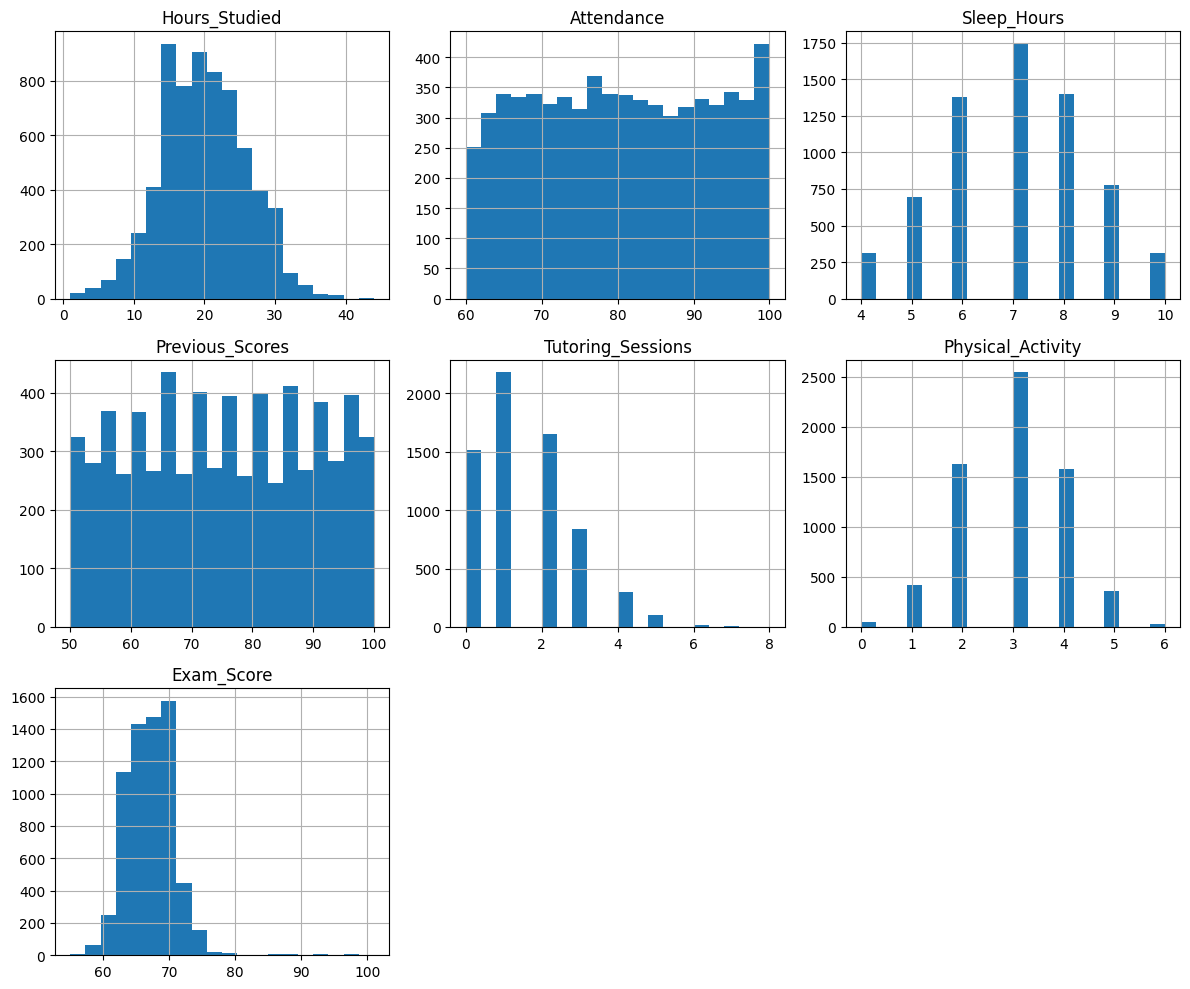


Correlation heatmap (numeric columns only):


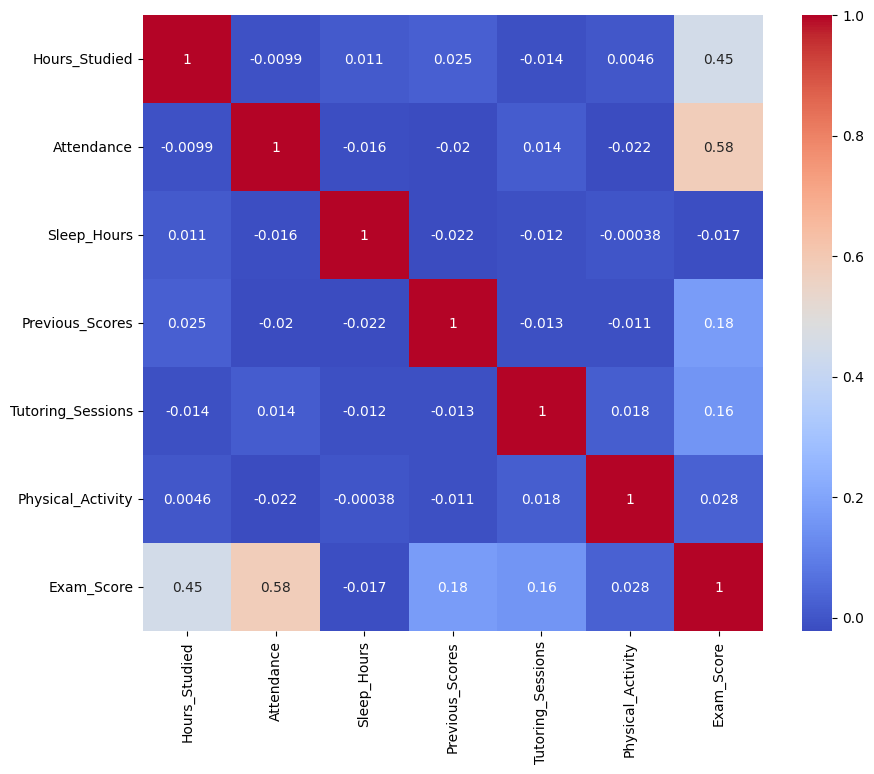


Step 5: Data exploration completed successfully!


In [6]:
# Step 5: Load and Explore Dataset (Full Corrected Script)

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2️⃣ Load dataset
data_path = "data/Student_PerformanceFactors.csv"  # <-- exact file name
try:
    df = pd.read_csv(data_path)
    print("✅ File loaded successfully!")
except FileNotFoundError:
    print("❌ File not found! Make sure it is in the 'data' folder and the name matches exactly.")
except PermissionError:
    print("❌ Permission denied! Check file properties.")

# 3️⃣ Explore dataset if loaded
if 'df' in locals():
    # Show first 5 rows
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    # Dataset info
    print("\nDataset info:")
    df.info()

    # Summary statistics for numeric columns
    print("\nSummary statistics (numeric columns):")
    display(df.describe())

    # Check for missing values
    print("\nMissing values in each column:")
    display(df.isnull().sum())

    # 4️⃣ Histograms for numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    print("\nHistograms of numeric columns:")
    df[numeric_cols].hist(figsize=(12,10), bins=20)
    plt.tight_layout()
    plt.show()

    # 5️⃣ Correlation heatmap for numeric columns only
    print("\nCorrelation heatmap (numeric columns only):")
    plt.figure(figsize=(10,8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
    plt.show()

    # ✅ Step 5 complete
    print("\nStep 5: Data exploration completed successfully!")

In [7]:
# Step 6: Feature Engineering & Preprocessing

# 1️⃣ Import required libraries
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 2️⃣ Handle missing values
# Fill missing categorical columns with mode
categorical_cols_with_na = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in categorical_cols_with_na:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

print("✅ Missing values handled.")

# 3️⃣ Convert categorical columns to numeric
# List all categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply Label Encoding to convert strings to numbers
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical columns encoded.")

# 4️⃣ Split features (X) and target (y)
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

print("✅ Features and target separated.")

# 5️⃣ Standardize numeric columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("✅ Numeric features standardized.")

# 6️⃣ Check final preprocessed data
print("\nPreprocessed feature sample (first 5 rows):")
display(X.head())

print("\nTarget sample (first 5 rows):")
display(y.head())

print("\nStep 6: Feature engineering & preprocessing completed successfully!")

✅ Missing values handled.
✅ Categorical columns encoded.
✅ Features and target separated.
✅ Numeric features standardized.

Preprocessed feature sample (first 5 rows):


C:\Users\morsa\AppData\Local\Temp\ipykernel_14824\2410438501.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(mode_value, inplace=True)
C:\Users\morsa\AppData\Local\Temp\ipykernel_14824\2410438501.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is sp

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,0.504942,0.348375,-0.254249,-1.380517,-1.214685,-0.019796,-0.143800,-0.393061,0.285825,-1.213934,-0.284883,0.742375,0.661006,1.070550,0.031411,-0.342867,0.103120,0.717316,0.855746
1,-0.162822,-1.383736,-0.254249,0.913804,-1.214685,0.661399,-1.116110,-0.393061,0.285825,0.411451,1.062448,0.742375,0.661006,-1.575587,1.001199,-0.342867,-1.248688,-0.742280,-1.168570
2,0.671882,1.560853,0.901062,0.913804,0.823259,-0.019796,1.106313,0.884966,0.285825,0.411451,1.062448,0.742375,0.661006,-0.252518,1.001199,-0.342867,1.454927,0.717316,0.855746
3,1.506587,0.781403,-0.254249,0.913804,0.823259,0.661399,1.592469,0.884966,0.285825,-0.401242,1.062448,0.742375,0.661006,-1.575587,1.001199,-0.342867,0.103120,-0.742280,0.855746
4,-0.162822,1.041220,0.901062,0.913804,0.823259,-0.700990,-0.699406,0.884966,0.285825,1.224144,1.062448,-1.450726,0.661006,-0.252518,1.001199,-0.342867,-1.248688,0.717316,-1.168570



Target sample (first 5 rows):


0    67
1    61
2    74
3    71
4    70
Name: Exam_Score, dtype: int64


Step 6: Feature engineering & preprocessing completed successfully!


✅ Train/test split done.
Linear Regression MSE: 4.40
Decision Tree MSE: 11.43
Random Forest MSE: 4.85

✅ Best-performing model: LinearRegression
✅ Best model saved as best_model_LinearRegression.pkl


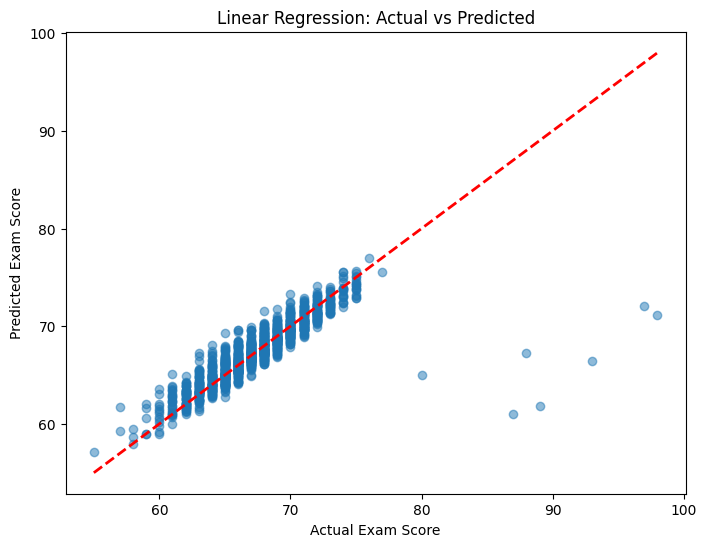


Sample prediction for first test row: 65.20

Step 7: Model training and evaluation completed successfully!


In [8]:
# Step 7: Model Training & Evaluation

# 1️⃣ Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib

# 2️⃣ Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Train/test split done.")

# 3️⃣ Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f"Linear Regression MSE: {mse_lr:.2f}")

# 4️⃣ Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f"Decision Tree MSE: {mse_dt:.2f}")

# 5️⃣ Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf:.2f}")

# 6️⃣ Determine best model based on MSE
mse_dict = {"LinearRegression": mse_lr, "DecisionTree": mse_dt, "RandomForest": mse_rf}
best_model_name = min(mse_dict, key=mse_dict.get)
print(f"\n✅ Best-performing model: {best_model_name}")

best_model = {"LinearRegression": lr_model, 
              "DecisionTree": dt_model, 
              "RandomForest": rf_model}[best_model_name]

# 7️⃣ Save best model
joblib.dump(best_model, f"best_model_{best_model_name}.pkl")
print(f"✅ Best model saved as best_model_{best_model_name}.pkl")

# 8️⃣ Scatter plot for Linear Regression predictions
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

# 9️⃣ Example prediction using the best model (first row of test set)
sample_input = X_test.iloc[[0]]  # keep it as DataFrame
sample_prediction = best_model.predict(sample_input)
print(f"\nSample prediction for first test row: {sample_prediction[0]:.2f}")

print("\nStep 7: Model training and evaluation completed successfully!")